# 04 — Síntese integrada (TCC)

Este é o notebook que **diferencia o TCC**. Os três anteriores estabeleceram cada
dimensão isoladamente; aqui elas se cruzam.

**Tese central:**
Se avaliarmos apenas correção (notebook 01), os modelos ficam quase empatados.
Se trocarmos a lente para correção + foco (notebook 02), a hierarquia muda.
Se ainda incluirmos custo (notebook 03), a recomendação muda mais uma vez.
**A escolha do modelo depende do critério de avaliação adotado.**

E mais: comparando a **ferramenta customizada** com **chats comerciais do mesmo
provedor**, vemos se vale o trabalho de construir uma RAG dedicada.

Estrutura:
1. Tabela mestre integrada (11 modelos × 3 dimensões)
2. Quadrante 2×2: correto × focado
3. Fronteira de Pareto multi-critério
4. Ferramenta vs Chat — head-to-head pareado por provedor
5. Score composto e ranking final TCC
6. Heatmap de dificuldade por categoria
7. Resumo executivo


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150,
    'font.size': 10, 'axes.titleweight': 'bold', 'axes.titlesize': 12,
})

PALETA_PROVEDOR = {'anthropic': '#D97757', 'openai': '#10A37F', 'deepseek': '#4D6BFE'}
PALETA_ORIGEM   = {'ferramenta': '#2E86AB', 'chat_comercial': '#E74C3C'}

def detecta_artefatos():
    candidatos = [Path('../artefatos'), Path('../../artefatos'), Path('artefatos'),
                  Path('../'), Path('.')]
    for c in candidatos:
        if (c / 'result_unificado_final.xlsx').exists():
            return c.resolve()
    raise FileNotFoundError('result_unificado_final.xlsx não encontrado.')
ART = detecta_artefatos()

def infere_provedor(modelo: str) -> str:
    m = modelo.lower()
    if 'claude' in m: return 'anthropic'
    if 'gpt' in m or 'chatgpt' in m: return 'openai'
    if 'deepseek' in m: return 'deepseek'
    return 'desconhecido'

df = pd.read_excel(ART / 'result_unificado_final.xlsx')
df['provedor'] = df['modelo'].apply(infere_provedor)
for col in ['input_tokens','output_tokens','custo_estimado_usd','n_invocacoes','latencia_s']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'{len(df)} respostas, {df.modelo.nunique()} modelos, {df.edital.nunique()} editais')


1650 respostas, 11 modelos, 3 editais


## 1. Tabela mestre integrada

Resumo das 3 dimensões para os 11 modelos. Custo, latência e n_invocações vêm
como NaN para os chats — naturalmente não temos como medir isso.


In [2]:
mestre = (df.groupby(['origem_resultado','provedor','modelo'])
          .agg(n=('id','count'),
               aval_final=('avaliacao_final','mean'),
               taxa_perfeita=('avaliacao_final', lambda x: (x==1).mean()),
               concisao=('concisao_score','mean'),
               tokens_resp=('resposta_tokens_tiktoken','mean'),
               custo_med_usd=('custo_estimado_usd','mean'),
               latencia_p50_s=('latencia_s','median'),
               n_invocacoes=('n_invocacoes','mean'))
          .reset_index().sort_values('aval_final', ascending=False))
print(mestre.round(3).to_string(index=False))


origem_resultado  provedor            modelo   n  aval_final  taxa_perfeita  concisao  tokens_resp  custo_med_usd  latencia_p50_s  n_invocacoes
      ferramenta    openai           gpt-5.5 150       0.997          0.993     0.973      117.207          0.055          19.505         2.347
      ferramenta anthropic   claude-opus-4-7 150       0.977          0.953     0.487      271.707          0.107          10.620         2.240
      ferramenta anthropic claude-sonnet-4-6 150       0.973          0.947     0.360      321.400          0.054          11.675         2.333
      ferramenta  deepseek deepseek-v4-flash 150       0.970          0.940     0.560      264.573          0.002           7.505         2.407
      ferramenta  deepseek   deepseek-v4-pro 150       0.963          0.927     0.473      296.453          0.025          15.850         2.407
      ferramenta    openai           gpt-5.4 150       0.963          0.940     0.973      107.413          0.024           4.890       

## 2. Quadrante 2×2 — correto × focado

Cada modelo é um ponto:
- Eixo X = `avaliacao_final` (correção)
- Eixo Y = `concisao_score` médio (foco)

Quem está no quadrante superior-direito (acima das medianas em ambos) é candidato a
"melhor modelo para essa tarefa".


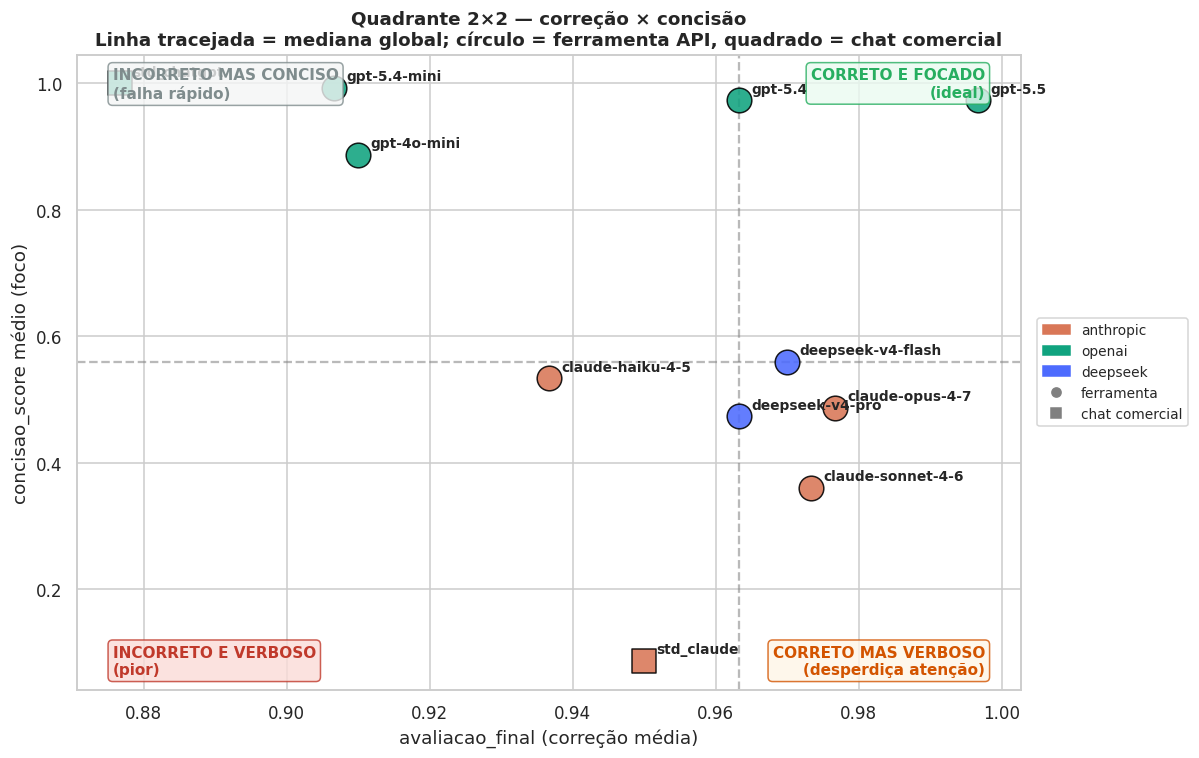


Modelos no quadrante CORRETO E FOCADO:
 modelo provedor  aval_final  concisao
gpt-5.5   openai       0.997     0.973


In [3]:
ranking = mestre.copy()
x_lim = ranking['aval_final'].median()
y_lim = ranking['concisao'].median()

fig, ax = plt.subplots(figsize=(11, 7))
cores = [PALETA_PROVEDOR[p] for p in ranking['provedor']]
markers = ['o' if o=='ferramenta' else 's' for o in ranking['origem_resultado']]
for _, r in ranking.iterrows():
    m = 'o' if r['origem_resultado']=='ferramenta' else 's'
    ax.scatter(r['aval_final'], r['concisao'],
               c=PALETA_PROVEDOR[r['provedor']], s=260, marker=m,
               edgecolor='black', linewidth=1, alpha=0.88, zorder=3)
    ax.annotate(r['modelo'], (r['aval_final'], r['concisao']),
                xytext=(8, 5), textcoords='offset points',
                fontsize=9, fontweight='bold')

ax.axvline(x_lim, ls='--', color='gray', alpha=0.55)
ax.axhline(y_lim, ls='--', color='gray', alpha=0.55)

# Anotar quadrantes
xlo, xhi = ax.get_xlim(); ylo, yhi = ax.get_ylim()
ax.text(xhi-0.005, yhi-0.02, 'CORRETO E FOCADO\n(ideal)',
        ha='right', va='top', fontsize=10, fontweight='bold', color='#27ae60',
        bbox=dict(boxstyle='round', facecolor='#eafaf1', edgecolor='#27ae60', alpha=0.8))
ax.text(xlo+0.005, ylo+0.02, 'INCORRETO E VERBOSO\n(pior)',
        ha='left', va='bottom', fontsize=10, fontweight='bold', color='#c0392b',
        bbox=dict(boxstyle='round', facecolor='#fadbd8', edgecolor='#c0392b', alpha=0.8))
ax.text(xhi-0.005, ylo+0.02, 'CORRETO MAS VERBOSO\n(desperdiça atenção)',
        ha='right', va='bottom', fontsize=10, fontweight='bold', color='#d35400',
        bbox=dict(boxstyle='round', facecolor='#fef5e7', edgecolor='#d35400', alpha=0.8))
ax.text(xlo+0.005, yhi-0.02, 'INCORRETO MAS CONCISO\n(falha rápido)',
        ha='left', va='top', fontsize=10, fontweight='bold', color='#7f8c8d',
        bbox=dict(boxstyle='round', facecolor='#f4f6f6', edgecolor='#7f8c8d', alpha=0.8))

ax.set_xlabel('avaliacao_final (correção média)')
ax.set_ylabel('concisao_score médio (foco)')
ax.set_title('Quadrante 2×2 — correção × concisão\n'
             'Linha tracejada = mediana global; círculo = ferramenta API, quadrado = chat comercial')

patches = [mpatches.Patch(color=c, label=p) for p,c in PALETA_PROVEDOR.items()]
patches += [plt.Line2D([0],[0], marker='o', color='gray', label='ferramenta', linestyle=''),
            plt.Line2D([0],[0], marker='s', color='gray', label='chat comercial', linestyle='')]
ax.legend(handles=patches, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=9)
plt.tight_layout(); plt.show()

quadrante_ideal = ranking[(ranking['aval_final'] > x_lim) & (ranking['concisao'] > y_lim)]
print('\nModelos no quadrante CORRETO E FOCADO:')
print(quadrante_ideal[['modelo','provedor','aval_final','concisao']].round(3).to_string(index=False))


## 3. Pareto multi-critério: correção × custo, com cor = concisão

Junta as 3 dimensões num gráfico: X = custo, Y = correção, **cor = concisão**.
Aplicável só aos 9 modelos da ferramenta. A fronteira de Pareto liga os pontos
não dominados em (custo↓, correção↑).


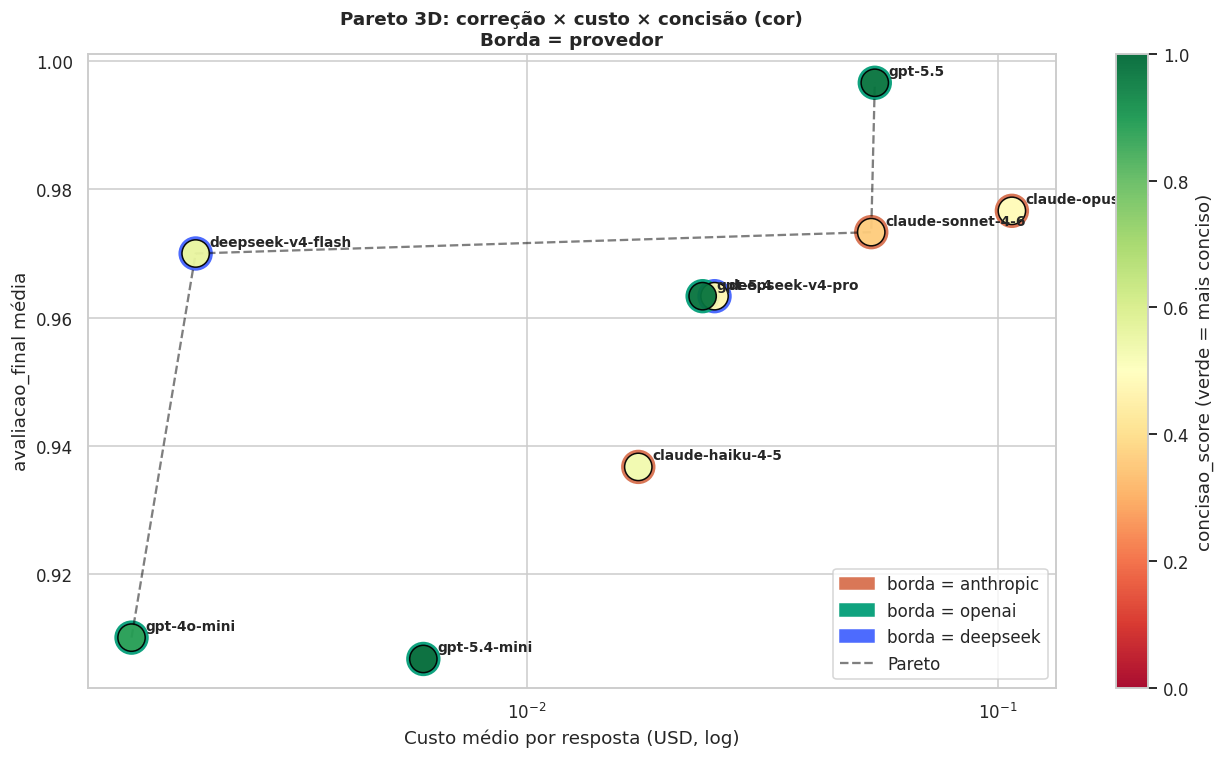

Modelos na fronteira de Pareto (correção × custo):
  gpt-4o-mini             $0.00145  aval=0.910  concisao=0.887
  deepseek-v4-flash       $0.00198  aval=0.970  concisao=0.560
  claude-sonnet-4-6       $0.05379  aval=0.973  concisao=0.360
  gpt-5.5                 $0.05473  aval=0.997  concisao=0.973


In [4]:
fer = ranking[ranking['origem_resultado']=='ferramenta'].copy()

def pareto_frontier(xs, ys, modelos):
    pts = sorted(zip(xs, ys, modelos))
    front = []; best_y = -np.inf
    for x, y, m in pts:
        if y > best_y:
            front.append((x, y, m)); best_y = y
    return front

front = pareto_frontier(fer['custo_med_usd'].values, fer['aval_final'].values, fer['modelo'].values)

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(fer['custo_med_usd'], fer['aval_final'],
                c=fer['concisao'], cmap='RdYlGn', vmin=0, vmax=1,
                s=320, edgecolor='black', linewidth=1.0, alpha=0.95, zorder=3)

# Marcadores secundários para mostrar o provedor (cor da borda)
for _, r in fer.iterrows():
    ax.scatter(r['custo_med_usd'], r['aval_final'],
               facecolor='none', s=400, edgecolor=PALETA_PROVEDOR[r['provedor']],
               linewidth=2.5, zorder=2)
    ax.annotate(r['modelo'], (r['custo_med_usd'], r['aval_final']),
                xytext=(9, 5), textcoords='offset points', fontsize=9, fontweight='bold')

# Fronteira
fx = [p[0] for p in front]; fy = [p[1] for p in front]
ax.plot(fx, fy, '--', color='black', alpha=0.5, linewidth=1.5, label='Fronteira Pareto')

ax.set_xscale('log')
ax.set_xlabel('Custo médio por resposta (USD, log)')
ax.set_ylabel('avaliacao_final média')
ax.set_title('Pareto 3D: correção × custo × concisão (cor)\nBorda = provedor')
cbar = plt.colorbar(sc, ax=ax); cbar.set_label('concisao_score (verde = mais conciso)')

patches = [mpatches.Patch(color=c, label=f'borda = {p}') for p,c in PALETA_PROVEDOR.items()]
patches.append(plt.Line2D([0],[0], ls='--', color='black', alpha=0.5, label='Pareto'))
ax.legend(handles=patches, loc='lower right')

plt.tight_layout(); plt.show()

print('Modelos na fronteira de Pareto (correção × custo):')
for x, y, m in front:
    cm = fer[fer.modelo==m].iloc[0]
    print(f'  {m:22s}  ${x:.5f}  aval={y:.3f}  concisao={cm["concisao"]:.3f}')


## 4. Ferramenta vs Chat — head-to-head pareado por provedor

A pergunta direta: **vale a pena construir uma RAG customizada?**

Comparamos:
- Melhor modelo OpenAI da ferramenta vs `std_chatgpt`
- Melhor modelo Anthropic da ferramenta vs `std_claude`

Usamos teste pareado (mesma pergunta, mesmo edital).


 provedor      modelo_api  aval_api  concisao_api  tokens_api modelo_chat  aval_chat  concisao_chat  tokens_chat
   openai         gpt-5.5     0.997         0.973     117.207 std_chatgpt      0.877          1.000       61.100
anthropic claude-opus-4-7     0.977         0.487     271.707  std_claude      0.950          0.087      581.413


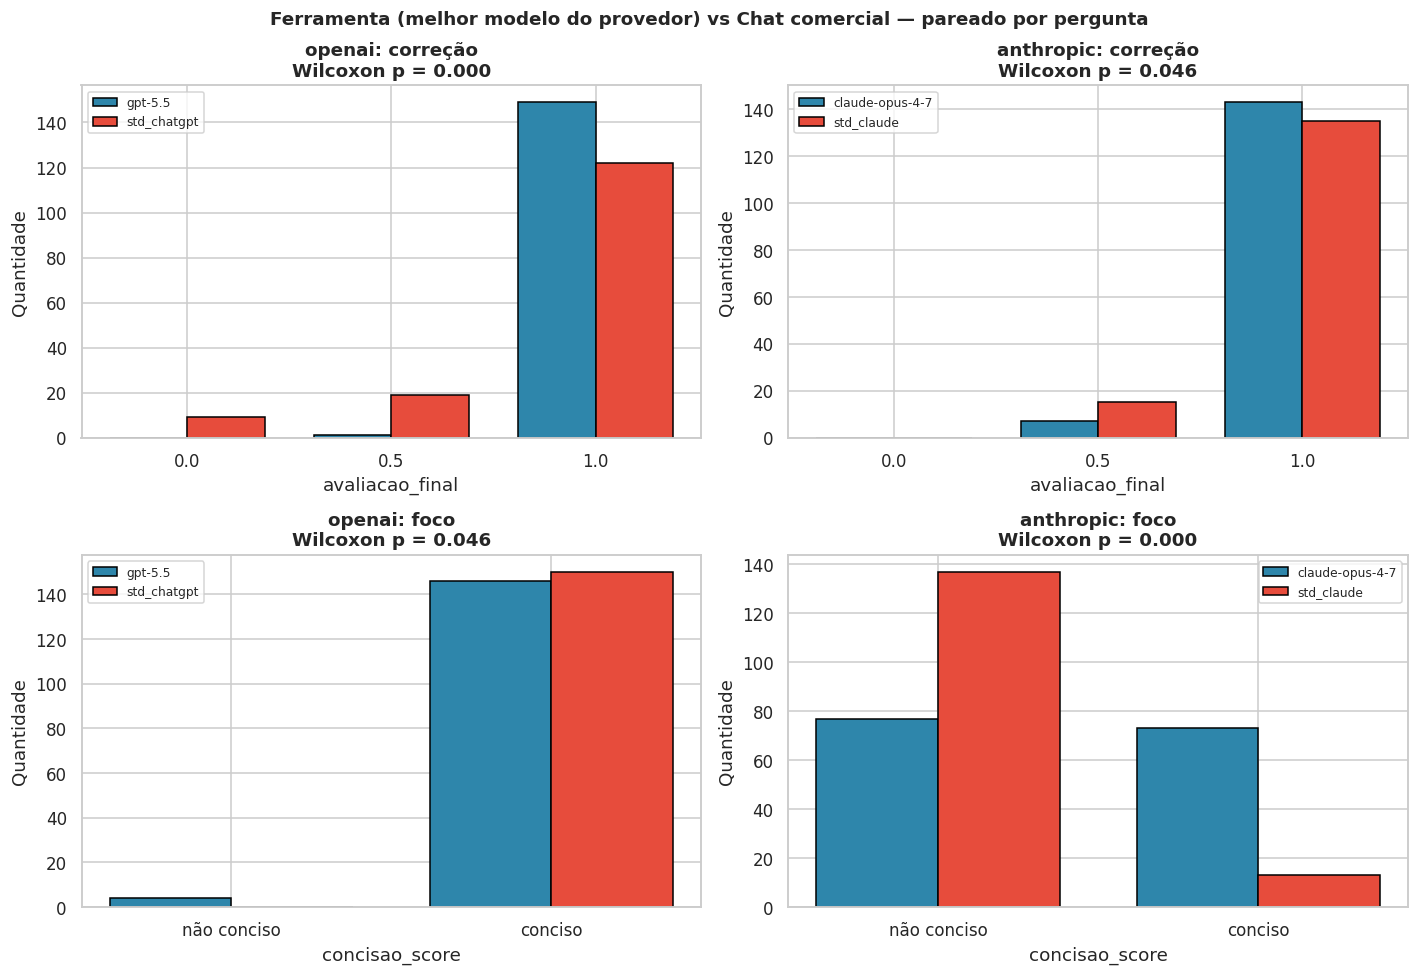

In [5]:
# Para cada provedor com chat disponível, pegar o melhor modelo da ferramenta
provedores_com_chat = {'openai': 'std_chatgpt', 'anthropic': 'std_claude'}

resumos = []
for prov, chat_modelo in provedores_com_chat.items():
    api_models = mestre[(mestre.origem_resultado=='ferramenta') & (mestre.provedor==prov)]
    melhor_api = api_models.sort_values('aval_final', ascending=False).iloc[0]['modelo']
    chat_row   = mestre[mestre.modelo == chat_modelo].iloc[0]
    api_row    = mestre[mestre.modelo == melhor_api].iloc[0]
    resumos.append({
        'provedor': prov,
        'modelo_api': melhor_api, 'aval_api': api_row['aval_final'],
        'concisao_api': api_row['concisao'], 'tokens_api': api_row['tokens_resp'],
        'modelo_chat': chat_modelo, 'aval_chat': chat_row['aval_final'],
        'concisao_chat': chat_row['concisao'], 'tokens_chat': chat_row['tokens_resp'],
    })
head2head = pd.DataFrame(resumos)
print(head2head.round(3).to_string(index=False))

# Teste pareado por (edital, id) — só pega perguntas que ambos responderam
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for col_idx, prov in enumerate(['openai','anthropic']):
    row = head2head[head2head.provedor==prov].iloc[0]
    api_m, chat_m = row['modelo_api'], row['modelo_chat']

    api_df = df[df.modelo==api_m][['edital','id','avaliacao_final','concisao_score']].rename(
        columns={'avaliacao_final':'aval_api','concisao_score':'conc_api'})
    chat_df = df[df.modelo==chat_m][['edital','id','avaliacao_final','concisao_score']].rename(
        columns={'avaliacao_final':'aval_chat','concisao_score':'conc_chat'})
    pareado = api_df.merge(chat_df, on=['edital','id'])

    # Teste de Wilcoxon (correção)
    diffs_aval = pareado['aval_api'] - pareado['aval_chat']
    if (diffs_aval != 0).any():
        w_stat, w_p = stats.wilcoxon(pareado['aval_api'], pareado['aval_chat'],
                                      zero_method='wilcox', alternative='two-sided')
    else:
        w_stat, w_p = (np.nan, 1.0)

    diffs_conc = pareado['conc_api'] - pareado['conc_chat']
    if (diffs_conc != 0).any():
        wc_stat, wc_p = stats.wilcoxon(pareado['conc_api'], pareado['conc_chat'],
                                        zero_method='wilcox', alternative='two-sided')
    else:
        wc_stat, wc_p = (np.nan, 1.0)

    # Barras: distribuição de avaliacao_final
    ax = axes[0, col_idx]
    notas = [0.0, 0.5, 1.0]; x = np.arange(len(notas)); w = 0.38
    cnt_api  = pareado['aval_api' ].value_counts().reindex(notas, fill_value=0)
    cnt_chat = pareado['aval_chat'].value_counts().reindex(notas, fill_value=0)
    ax.bar(x - w/2, cnt_api,  w, label=api_m,  color=PALETA_ORIGEM['ferramenta'], edgecolor='black')
    ax.bar(x + w/2, cnt_chat, w, label=chat_m, color=PALETA_ORIGEM['chat_comercial'], edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels([str(n) for n in notas])
    ax.set_xlabel('avaliacao_final'); ax.set_ylabel('Quantidade')
    ax.set_title(f'{prov}: correção\nWilcoxon p = {w_p:.3f}')
    ax.legend(fontsize=8)

    # Barras: distribuição de concisao
    ax = axes[1, col_idx]
    notas = [0, 1]; x = np.arange(len(notas)); w = 0.38
    cnt_api  = pareado['conc_api' ].value_counts().reindex(notas, fill_value=0)
    cnt_chat = pareado['conc_chat'].value_counts().reindex(notas, fill_value=0)
    ax.bar(x - w/2, cnt_api,  w, label=api_m,  color=PALETA_ORIGEM['ferramenta'], edgecolor='black')
    ax.bar(x + w/2, cnt_chat, w, label=chat_m, color=PALETA_ORIGEM['chat_comercial'], edgecolor='black')
    ax.set_xticks(x); ax.set_xticklabels(['não conciso','conciso'])
    ax.set_xlabel('concisao_score'); ax.set_ylabel('Quantidade')
    ax.set_title(f'{prov}: foco\nWilcoxon p = {wc_p:.3f}')
    ax.legend(fontsize=8)

plt.suptitle('Ferramenta (melhor modelo do provedor) vs Chat comercial — pareado por pergunta',
             fontweight='bold')
plt.tight_layout(); plt.show()


## 5. Score composto e ranking final TCC

Score normalizado que reflete a tese: correção e concisão pesam igual.
Para os modelos da ferramenta, adicionamos um critério de **custo penalizado**
(quanto mais barato, mais pontos). Isso responde a pergunta operacional:
*"se eu pudesse adotar UM modelo na ferramenta, qual seria?"*


RANKING — score_qualidade (correção + concisão, 11 modelos):
           modelo  provedor origem_resultado  aval_final  concisao  score_qualidade
          gpt-5.5    openai       ferramenta       0.997     0.973            0.985
          gpt-5.4    openai       ferramenta       0.963     0.973            0.847
deepseek-v4-flash  deepseek       ferramenta       0.970     0.560            0.648
  claude-opus-4-7 anthropic       ferramenta       0.977     0.487            0.636
     gpt-5.4-mini    openai       ferramenta       0.907     0.993            0.621
      gpt-4o-mini    openai       ferramenta       0.910     0.887            0.577
  deepseek-v4-pro  deepseek       ferramenta       0.963     0.473            0.573
claude-sonnet-4-6 anthropic       ferramenta       0.973     0.360            0.552
      std_chatgpt    openai   chat_comercial       0.877     1.000            0.500
 claude-haiku-4-5 anthropic       ferramenta       0.937     0.533            0.495
       std_clau

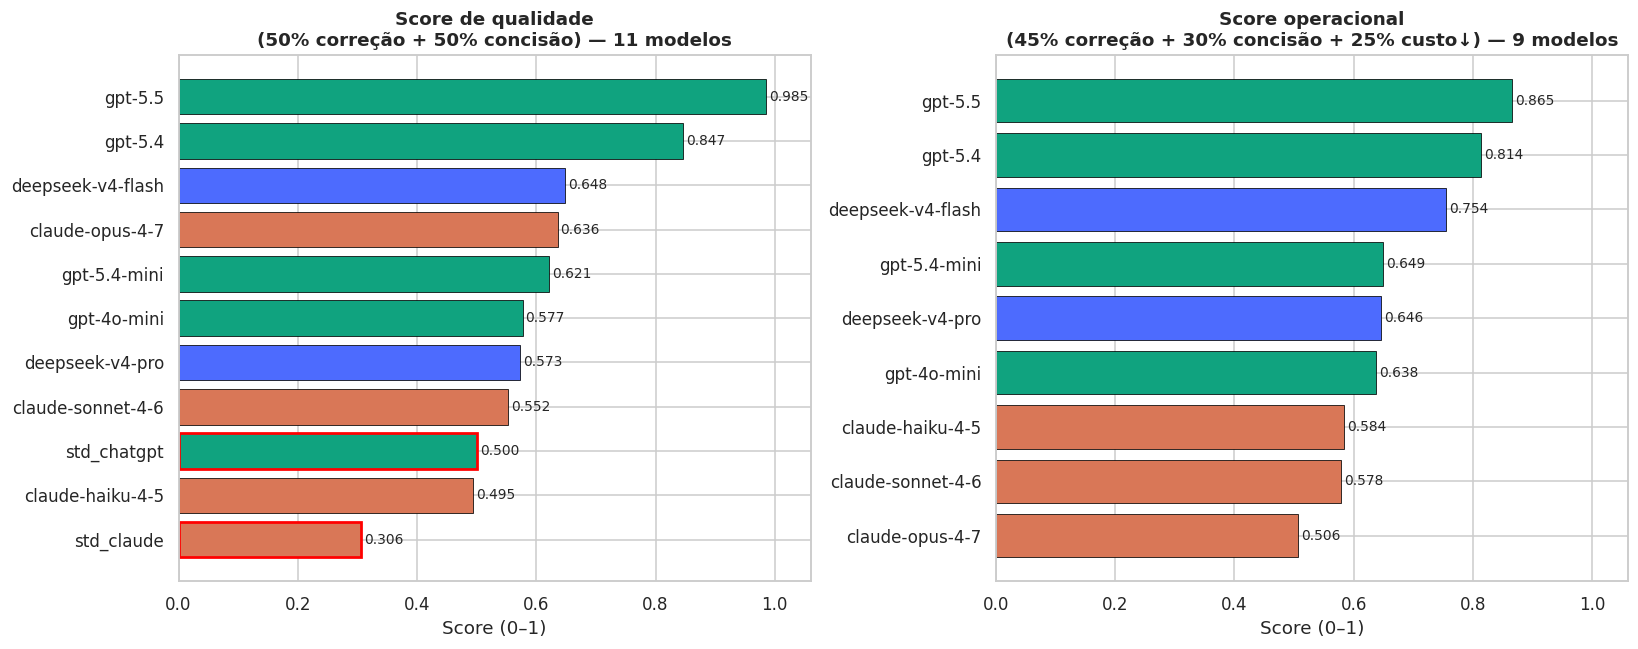

In [6]:
rk = mestre.copy()

# Normalização: min-max em cada coluna entre 0 e 1
def normaliza(s, inverter=False):
    s = s.copy()
    if s.isna().all() or s.max()==s.min():
        return s*0
    out = (s - s.min()) / (s.max() - s.min())
    return 1 - out if inverter else out

rk['n_aval']      = normaliza(rk['aval_final'])
rk['n_conc']      = normaliza(rk['concisao'])
rk['n_custo_inv'] = normaliza(rk['custo_med_usd'], inverter=True)  # menor é melhor

# Score TCC: média ponderada
# Versão 1: correção + concisão (compatível com os 11 modelos, inclui chats)
rk['score_qualidade'] = 0.5*rk['n_aval'] + 0.5*rk['n_conc']

# Versão 2: correção + concisão + custo (só ferramenta — chats não têm custo)
rk['score_operacional'] = (0.45*rk['n_aval'] + 0.30*rk['n_conc']
                            + 0.25*rk['n_custo_inv'])
rk.loc[rk['origem_resultado']=='chat_comercial','score_operacional'] = np.nan

# Ranking
print('RANKING — score_qualidade (correção + concisão, 11 modelos):')
print(rk.sort_values('score_qualidade', ascending=False)
      [['modelo','provedor','origem_resultado','aval_final','concisao','score_qualidade']]
      .round(3).to_string(index=False))

print('\nRANKING — score_operacional (correção + concisão + custo, 9 modelos):')
print(rk[rk.origem_resultado=='ferramenta'].sort_values('score_operacional', ascending=False)
      [['modelo','provedor','aval_final','concisao','custo_med_usd','score_operacional']]
      .round(4).to_string(index=False))

# Gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, col, titulo in [(axes[0], 'score_qualidade', 'Score de qualidade\n(50% correção + 50% concisão) — 11 modelos'),
                          (axes[1], 'score_operacional', 'Score operacional\n(45% correção + 30% concisão + 25% custo↓) — 9 modelos')]:
    sub = rk.dropna(subset=[col]).sort_values(col, ascending=True)
    cores = [PALETA_PROVEDOR[p] for p in sub['provedor']]
    edges = ['black' if o=='ferramenta' else 'red' for o in sub['origem_resultado']]
    lw    = [0.5 if o=='ferramenta' else 1.8 for o in sub['origem_resultado']]
    bars = ax.barh(sub['modelo'], sub[col], color=cores, edgecolor=edges, linewidth=lw)
    for b, v in zip(bars, sub[col].values):
        ax.text(v+0.005, b.get_y()+b.get_height()/2, f'{v:.3f}',
                va='center', fontsize=9)
    ax.set_xlim(0, 1.06)
    ax.set_xlabel('Score (0–1)'); ax.set_title(titulo)

plt.tight_layout(); plt.show()


## 6. Heatmap: dificuldade por categoria de pergunta

Quais categorias são mais difíceis? Cruzamos modelo × categoria com `avaliacao_final`
e separadamente com `concisao_score`.


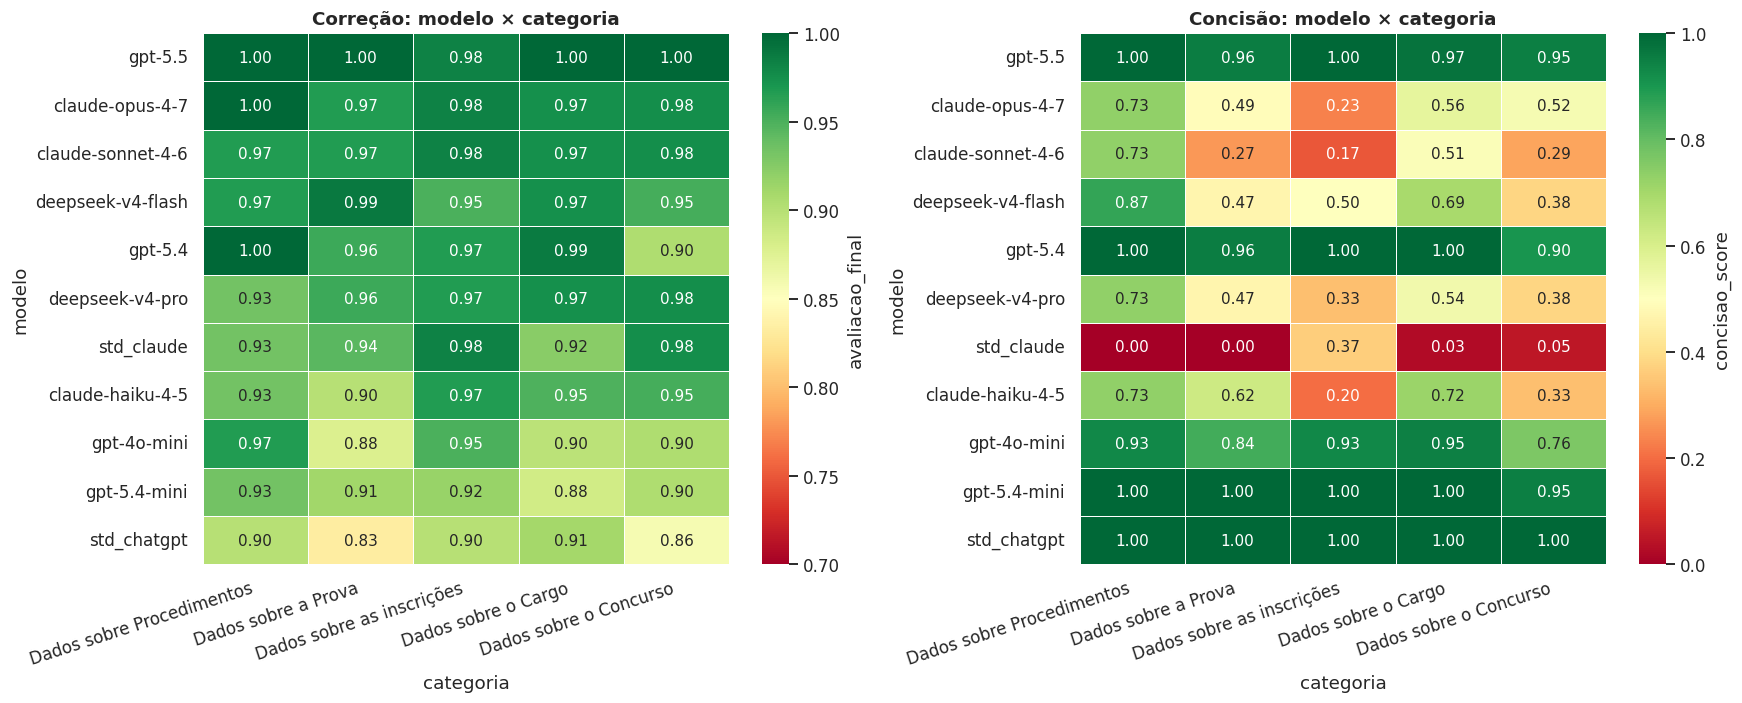


Média por categoria (geral):
                           aval_final  concisao    n
categoria                                           
Dados sobre a Prova             0.936     0.642  495
Dados sobre o Concurso          0.944     0.593  231
Dados sobre o Cargo             0.950     0.725  429
Dados sobre Procedimentos       0.958     0.794  165
Dados sobre as inscrições       0.959     0.612  330


In [7]:
ordem_score = df.groupby('modelo')['avaliacao_final'].mean().sort_values(ascending=False).index

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

heat_aval = df.pivot_table(index='modelo', columns='categoria', values='avaliacao_final',
                            aggfunc='mean').reindex(ordem_score)
sns.heatmap(heat_aval, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0.7, vmax=1.0,
            cbar_kws={'label':'avaliacao_final'}, linewidths=0.5, ax=axes[0])
axes[0].set_title('Correção: modelo × categoria')
plt.setp(axes[0].get_xticklabels(), rotation=18, ha='right')

heat_conc = df.pivot_table(index='modelo', columns='categoria', values='concisao_score',
                            aggfunc='mean').reindex(ordem_score)
sns.heatmap(heat_conc, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
            cbar_kws={'label':'concisao_score'}, linewidths=0.5, ax=axes[1])
axes[1].set_title('Concisão: modelo × categoria')
plt.setp(axes[1].get_xticklabels(), rotation=18, ha='right')

plt.tight_layout(); plt.show()

print('\nMédia por categoria (geral):')
print(df.groupby('categoria').agg(
    aval_final=('avaliacao_final','mean'),
    concisao=('concisao_score','mean'),
    n=('id','count')
).round(3).sort_values('aval_final').to_string())


## 7. Resumo executivo

Esta célula imprime o resumo executivo do TCC com os números reais da última execução.


In [8]:
print('━' * 78)
print('  RESUMO EXECUTIVO — ESTUDO INTEGRADO')
print('━' * 78)
print()
print(f'Modelos avaliados : 11  ({(mestre.origem_resultado=="ferramenta").sum()} ferramenta API + '
      f'{(mestre.origem_resultado=="chat_comercial").sum()} chats comerciais)')
print(f'Editais           : {df.edital.nunique()}  ({", ".join(sorted(df.edital.unique()))})')
print(f'Perguntas/edital  : {df.groupby("edital")["id"].nunique().iloc[0]}')
print(f'Total respostas   : {len(df):,}')
print()
print('─' * 78)
print('  ACHADO 1 — Correção quase satura: a escolha de modelo não pode parar aqui')
print('─' * 78)
amin, amax = mestre['aval_final'].min(), mestre['aval_final'].max()
print(f'  avaliacao_final: {amin:.3f} a {amax:.3f}  (spread = {amax-amin:.3f})')
print()
print('─' * 78)
print('  ACHADO 2 — Concisão separa fortemente os modelos')
print('─' * 78)
cmin, cmax = mestre['concisao'].min(), mestre['concisao'].max()
print(f'  concisao_score: {cmin:.3f} a {cmax:.3f}  (spread = {cmax-cmin:.3f})')
mais_conc = mestre.loc[mestre['concisao'].idxmax(), 'modelo']
mens_conc = mestre.loc[mestre['concisao'].idxmin(), 'modelo']
print(f'  Mais conciso:  {mais_conc}   (taxa = {cmax:.1%})')
print(f'  Menos conciso: {mens_conc}   (taxa = {cmin:.1%})')
print()
print('─' * 78)
print('  ACHADO 3 — Custo varia em ordens de grandeza entre modelos da ferramenta')
print('─' * 78)
fer = mestre[mestre.origem_resultado=='ferramenta']
cu_min, cu_max = fer['custo_med_usd'].min(), fer['custo_med_usd'].max()
print(f'  custo médio por resposta: ${cu_min:.5f} a ${cu_max:.5f}  ({cu_max/cu_min:.0f}× de diferença)')
mais_barato = fer.loc[fer['custo_med_usd'].idxmin(), 'modelo']
mais_caro   = fer.loc[fer['custo_med_usd'].idxmax(), 'modelo']
print(f'  Mais barato: {mais_barato}   (${cu_min:.5f})')
print(f'  Mais caro  : {mais_caro}   (${cu_max:.5f})')
print()
print('─' * 78)
print('  RECOMENDAÇÃO FINAL — ranking por score_operacional (ferramenta)')
print('─' * 78)
top3_op = rk[rk.origem_resultado=='ferramenta'].sort_values('score_operacional', ascending=False).head(3)
for i, (_, r) in enumerate(top3_op.iterrows(), 1):
    print(f'  {i}º  {r["modelo"]:22s}  score = {r["score_operacional"]:.3f}')
    print(f'       aval={r["aval_final"]:.3f}, conc={r["concisao"]:.3f}, custo=${r["custo_med_usd"]:.5f}')

print()
print('─' * 78)
print('  FERRAMENTA vs CHAT COMERCIAL — vale construir a RAG customizada?')
print('─' * 78)
for prov, chat in [('openai','std_chatgpt'), ('anthropic','std_claude')]:
    melhor = mestre[(mestre.origem_resultado=='ferramenta')&(mestre.provedor==prov)].sort_values('aval_final', ascending=False).iloc[0]
    cmm = mestre[mestre.modelo==chat].iloc[0]
    delta_aval = melhor['aval_final'] - cmm['aval_final']
    delta_conc = melhor['concisao'] - cmm['concisao']
    print(f'  {prov.upper()}:  ferramenta = {melhor["modelo"]}  vs  chat = {chat}')
    print(f'    correção:  {melhor["aval_final"]:.3f} (fer) - {cmm["aval_final"]:.3f} (chat) = Δ {delta_aval:+.3f}')
    print(f'    concisão:  {melhor["concisao"]:.3f} (fer) - {cmm["concisao"]:.3f} (chat) = Δ {delta_conc:+.3f}')
print('━' * 78)


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  RESUMO EXECUTIVO — ESTUDO INTEGRADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Modelos avaliados : 11  (9 ferramenta API + 2 chats comerciais)
Editais           : 3  (bndes, cvm, petrobras)
Perguntas/edital  : 50
Total respostas   : 1,650

──────────────────────────────────────────────────────────────────────────────
  ACHADO 1 — Correção quase satura: a escolha de modelo não pode parar aqui
──────────────────────────────────────────────────────────────────────────────
  avaliacao_final: 0.877 a 0.997  (spread = 0.120)

──────────────────────────────────────────────────────────────────────────────
  ACHADO 2 — Concisão separa fortemente os modelos
──────────────────────────────────────────────────────────────────────────────
  concisao_score: 0.087 a 1.000  (spread = 0.913)
  Mais conciso:  std_chatgpt   (taxa = 100.0%)
  Menos conciso: std_claude   (taxa = 8.7%)

─────